In [1]:
import numpy as np 
from causal_graph_comparison import *

Detected non-Linux system, using scratch directory:  /Users/cisaicu/dev/mila/scratch


In [2]:
data_dir = f"{SCRATCH_DIR}/data/SAVAR_DATA_TEST"

In [3]:
# weights = np.load('{data_dir}/modes_4_tl_10000_isforced_False_difficulty_easy_noisestrength_0.2_seasonality_False_overlap_False_mode_weights.npy')
# weights = np.load('{data_dir}/modes_9_tl_10000_isforced_False_difficulty_hard_noisestrength_0.2_seasonality_False_overlap_False_mode_weights.npy')
weights = np.load(f'{data_dir}/modes_4_tl_10000_isforced_False_difficulty_med_easy_noisestrength_0.2_seasonality_False_overlap_False_mode_weights.npy')

In [4]:
# modes = np.load(f'{data_dir}/modes_4_tl_10000_isforced_False_difficulty_easy_noisestrength_0.2_seasonality_False_overlap_False_modes.npy')
# modes = np.load(f'{data_dir}/modes_9_tl_10000_isforced_False_difficulty_hard_noisestrength_0.2_seasonality_False_overlap_False_modes.npy')
modes = np.load(f'{data_dir}/modes_4_tl_10000_isforced_False_difficulty_med_easy_noisestrength_0.2_seasonality_False_overlap_False_modes.npy')

In [5]:
# modes_noise = np.load(f'{data_dir}/modes_4_tl_10000_isforced_False_difficulty_easy_noisestrength_0.2_seasonality_False_overlap_False_noise_modes.npy')
# modes_noise = np.load(f'{data_dir}/modes_9_tl_10000_isforced_False_difficulty_hard_noisestrength_0.2_seasonality_False_overlap_False_noise_modes.npy')
modes_noise = np.load(f'{data_dir}/modes_4_tl_10000_isforced_False_difficulty_med_easy_noisestrength_0.2_seasonality_False_overlap_False_noise_modes.npy')

In [6]:
# parameters = np.load(f'{data_dir}/modes_4_tl_10000_isforced_False_difficulty_easy_noisestrength_0.2_seasonality_False_overlap_False_parameters.npy', allow_pickle=True)
# parameters = np.load(f'{data_dir}/modes_9_tl_10000_isforced_False_difficulty_hard_noisestrength_0.2_seasonality_False_overlap_False_parameters.npy', allow_pickle=True)
parameters = np.load(f'{data_dir}/modes_4_tl_10000_isforced_False_difficulty_med_easy_noisestrength_0.2_seasonality_False_overlap_False_parameters.npy', allow_pickle=True)

In [7]:
# data = np.load(f'{data_dir}/modes_4_tl_10000_isforced_False_difficulty_easy_noisestrength_0.2_seasonality_False_overlap_False.npy')
# data = np.load(f'{data_dir}/modes_9_tl_10000_isforced_False_difficulty_hard_noisestrength_0.2_seasonality_False_overlap_False.npy')
data = np.load(f'{data_dir}/modes_4_tl_10000_isforced_False_difficulty_med_easy_noisestrength_0.2_seasonality_False_overlap_False.npy')

In [8]:
print("Data shape: ", data.shape)
print("Parameters shape: ", parameters.shape)
print("Modes shape: ", modes.shape)
print("Modes noise shape: ", modes_noise.shape)
print("Weights shape: ", weights.shape)

Data shape:  (1600, 10000)
Parameters shape:  ()
Modes shape:  (40, 40)
Modes noise shape:  (40, 40)
Weights shape:  (4, 40, 40)


In [8]:
parameters

array({'name': 'modes_4_tl_10000_isforced_False_difficulty_med_easy_noisestrength_0.2_seasonality_False_overlap_False', 'nx': 40, 'ny': 40, 'T': 10000, 'N': 4, 'links_coeffs': {0: [((0, -2), 0.5), ((2, -4), 0.48)], 1: [((1, -2), 0.17), ((0, -4), 0.28)], 2: [((2, -3), 0.29), ((0, -5), 0.36)], 3: [((3, -3), 0.17), ((2, -5), 0.68)]}},
      dtype=object)

In [9]:
modes

array([[1.93749631e-05, 3.17236194e-05, 4.74893920e-05, ...,
        3.64399321e-07, 6.76437795e-08, 1.03833399e-08],
       [7.20506026e-05, 1.21931901e-04, 1.88655342e-04, ...,
        1.65822048e-06, 3.13161571e-07, 4.89050326e-08],
       [2.23626108e-04, 3.91147102e-04, 6.25503520e-04, ...,
        6.46872353e-06, 1.24285557e-06, 1.97461138e-07],
       ...,
       [8.57609984e-08, 5.12943921e-07, 2.65914917e-06, ...,
        5.79019107e-03, 4.07771082e-03, 2.58299177e-03],
       [1.76285974e-08, 1.12730076e-07, 6.24819526e-07, ...,
        2.95080403e-03, 2.22047092e-03, 1.50290969e-03],
       [3.21920795e-09, 2.20096457e-08, 1.30427698e-07, ...,
        1.29900674e-03, 1.04447325e-03, 7.55381438e-04]])

<Figure size 1500x800 with 0 Axes>

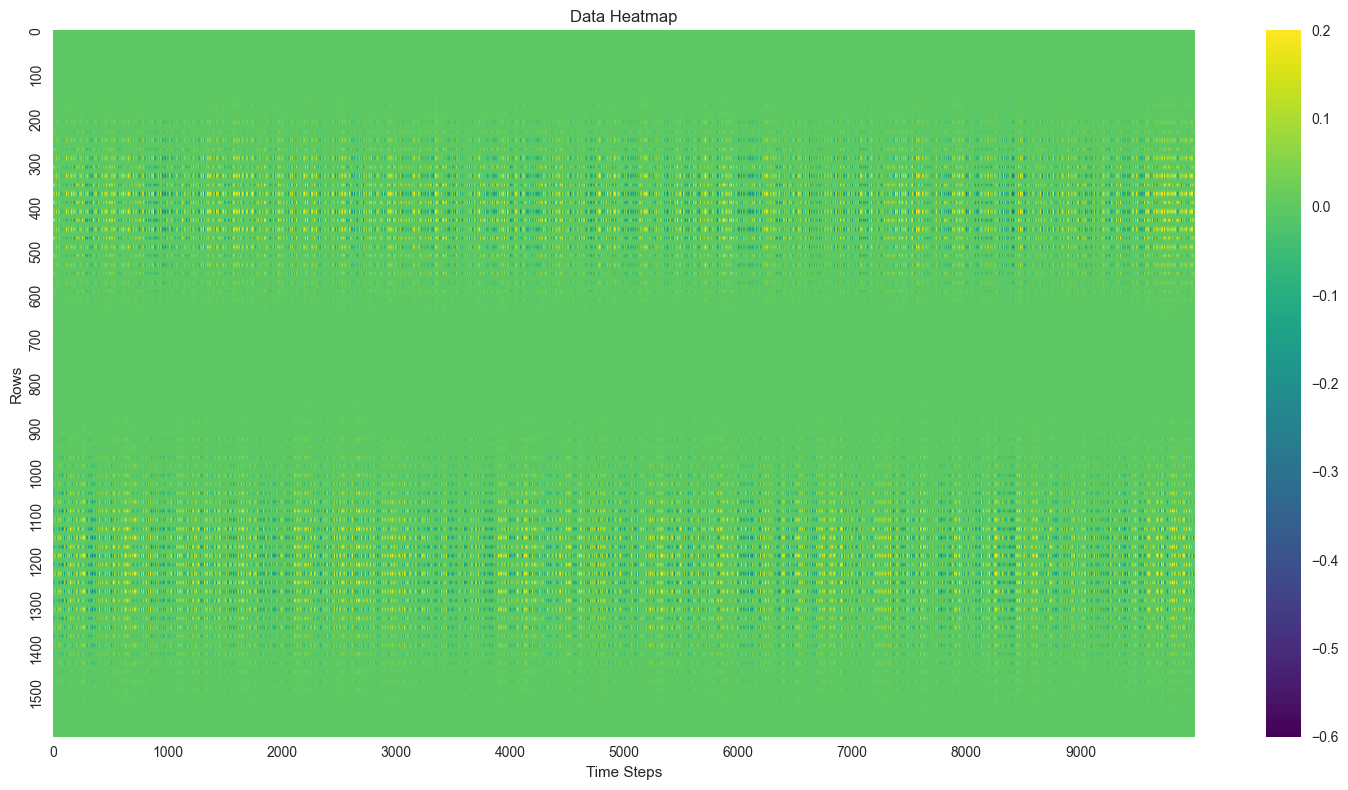

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for better visualization
plt.style.use('seaborn-v0_8')  # or you can use 'seaborn-darkgrid', 'seaborn-whitegrid', etc.

# Create a figure with a larger size
plt.figure(figsize=(15, 8))

# If you want to see the full data as a heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(data, cmap='viridis', xticklabels=1000, yticklabels=100, vmin=-0.6, vmax=0.2)
plt.title('Data Heatmap')
plt.xlabel('Time Steps')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()

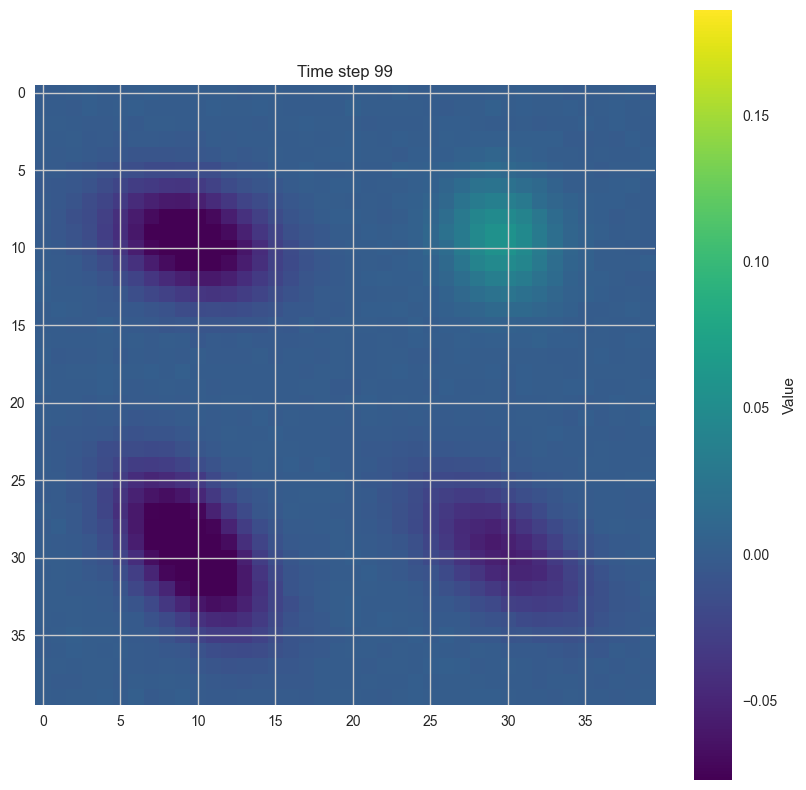

In [17]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# Reshape the data
# data_reshaped = data.reshape(20, 20, 10000)
# data_reshaped = data.reshape(30, 30, 10000)
data_reshaped = data.reshape(40, 40, 10000)
data_reshaped = data_reshaped[:,:,:100]

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 10))

# Create the initial image
im = ax.imshow(data_reshaped[:, :, 0], cmap='viridis')
plt.colorbar(im, ax=ax, label='Value')

# Function to update the image for each frame
def update(frame):
    im.set_array(data_reshaped[:, :, frame])
    ax.set_title(f'Time step {frame}')
    return [im]

# Create the animation
ani = animation.FuncAnimation(fig, update, frames=range(0, 10000, 100), 
                            interval=100, blit=True)

# Save the animation to a file
ani.save('evolution_animation.gif', writer='pillow', fps=2)

# If you want to display it in the notebook
from IPython.display import HTML
HTML(ani.to_jshtml())

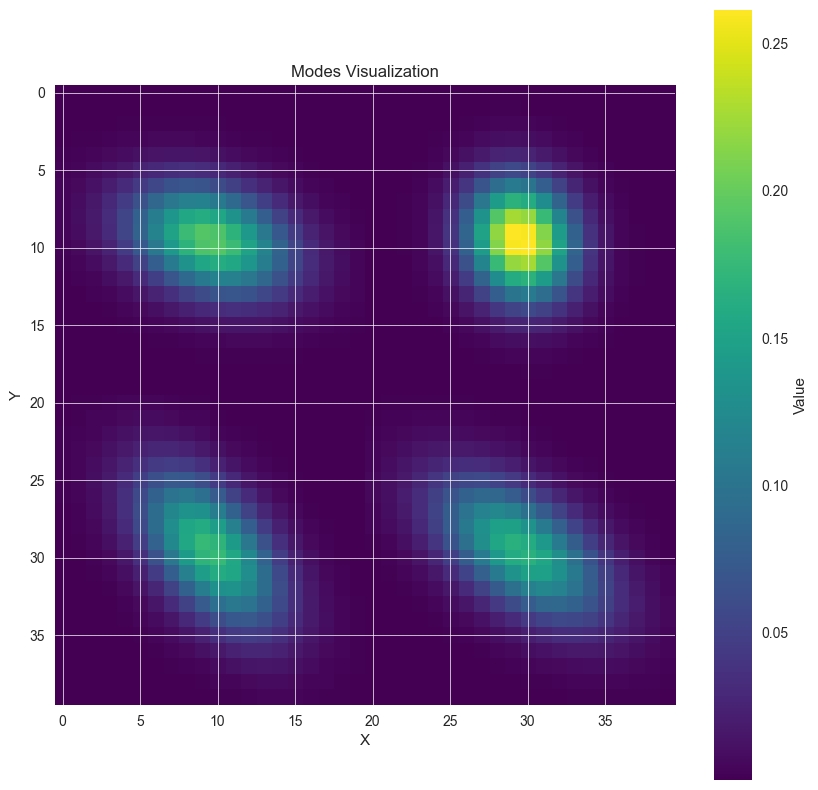

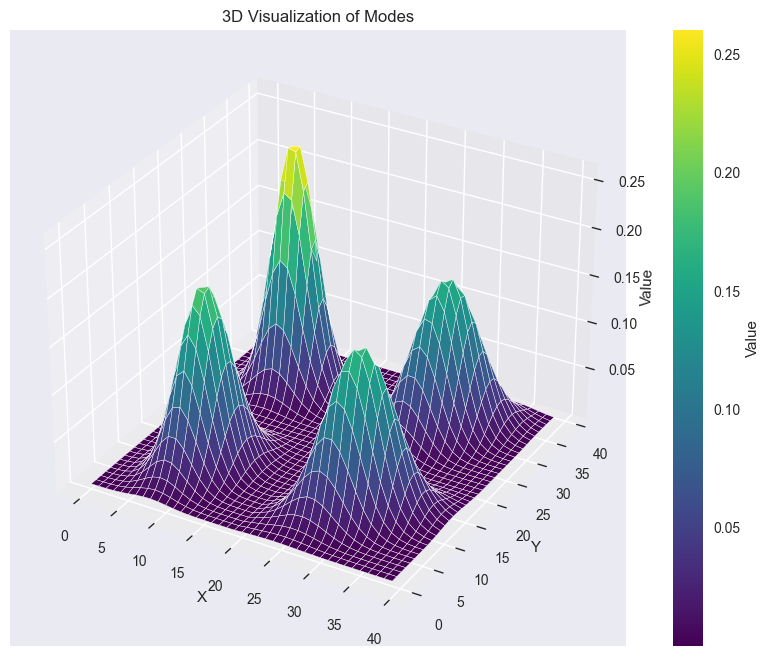

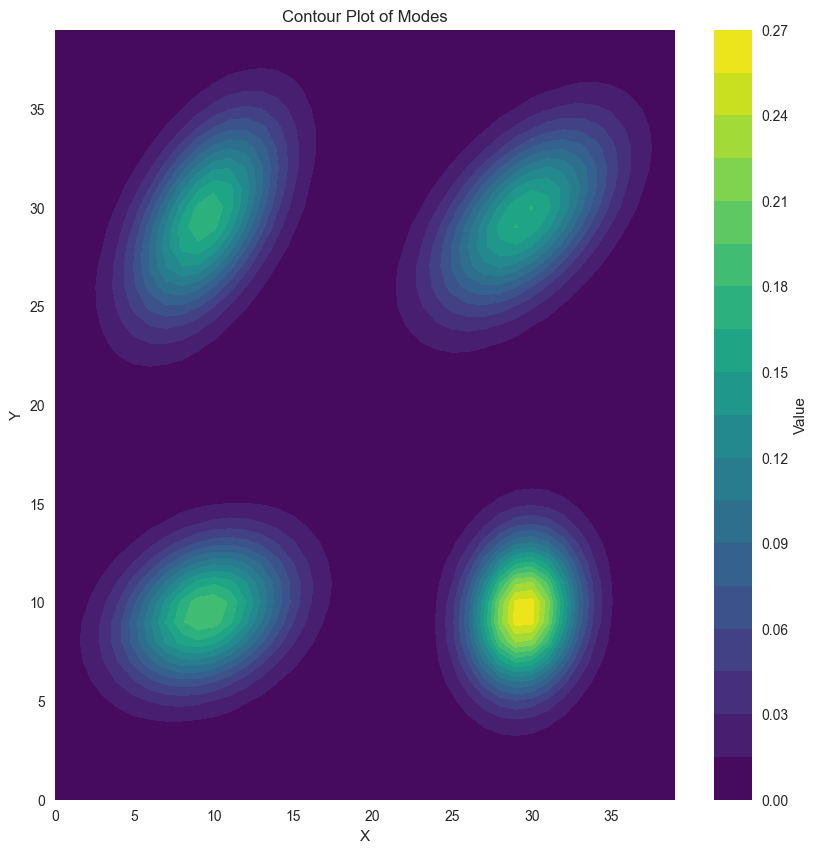

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with a larger size
plt.figure(figsize=(10, 10))

# Plot the modes as a heatmap
plt.imshow(modes, cmap='viridis')
plt.colorbar(label='Value')
plt.title('Modes Visualization')
plt.xlabel('X')
plt.ylabel('Y')

# Add grid lines to make it easier to see the structure
plt.grid(True, which='both', color='white', linewidth=0.5)

plt.show()

# If you want to see the modes in 3D
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D surface plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Create coordinate matrices
x = np.arange(modes.shape[0])
y = np.arange(modes.shape[1])
X, Y = np.meshgrid(x, y)

# Plot the surface
surf = ax.plot_surface(X, Y, modes.T, cmap='viridis')

# Add a color bar
fig.colorbar(surf, ax=ax, label='Value')

# Set labels and title
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Value')
ax.set_title('3D Visualization of Modes')

plt.show()

# If you want to see the modes as a contour plot
plt.figure(figsize=(10, 10))
contour = plt.contourf(modes, levels=20, cmap='viridis')
plt.colorbar(contour, label='Value')
plt.title('Contour Plot of Modes')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()